# Stereo template matching/block matching


In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import data

plt.gray()

<Figure size 640x480 with 0 Axes>

Start by loading a set of corresponding left and right image. We also resize the images since the computations we expect to do can take a long time to process. Resizing is optional, but recommended atleast until you have verified your computer is capable of doing the computations within reasonable time.

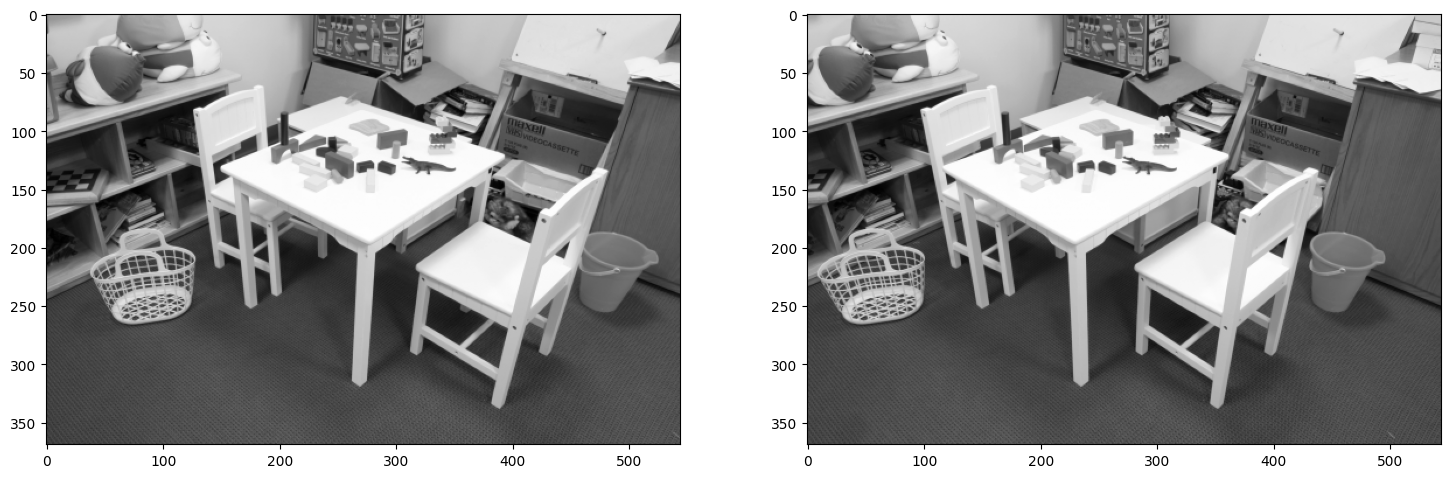

In [3]:
# load the images
img_left = cv2.imread("playtable_left.png")
img_right = cv2.imread("playtable_right.png")

# rescale images (can be left out)
img_size = (int(img_left.shape[1]/5), int(img_left.shape[0]/5))
img_left = cv2.resize(img_left, img_size, interpolation=cv2.INTER_AREA)
img_right = cv2.resize(img_right, img_size, interpolation=cv2.INTER_AREA)

# convert images to grayscale for template matching
gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

f, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(18,18))
ax_left.imshow(gray_left)
ax_right.imshow(gray_right)

Next step is to create a disparity map based on the two stereo images. This is done using the same procedure as we did with exercise 1, except now we look for blocks of pixel from the left image in the right image, or vice versa.

## Exercise 2.1
You will have to play with the below parameters until you find a good solution that gives a representative 3D projection. Reflect/search on what those parameters actually mean and how they influence the outcome.

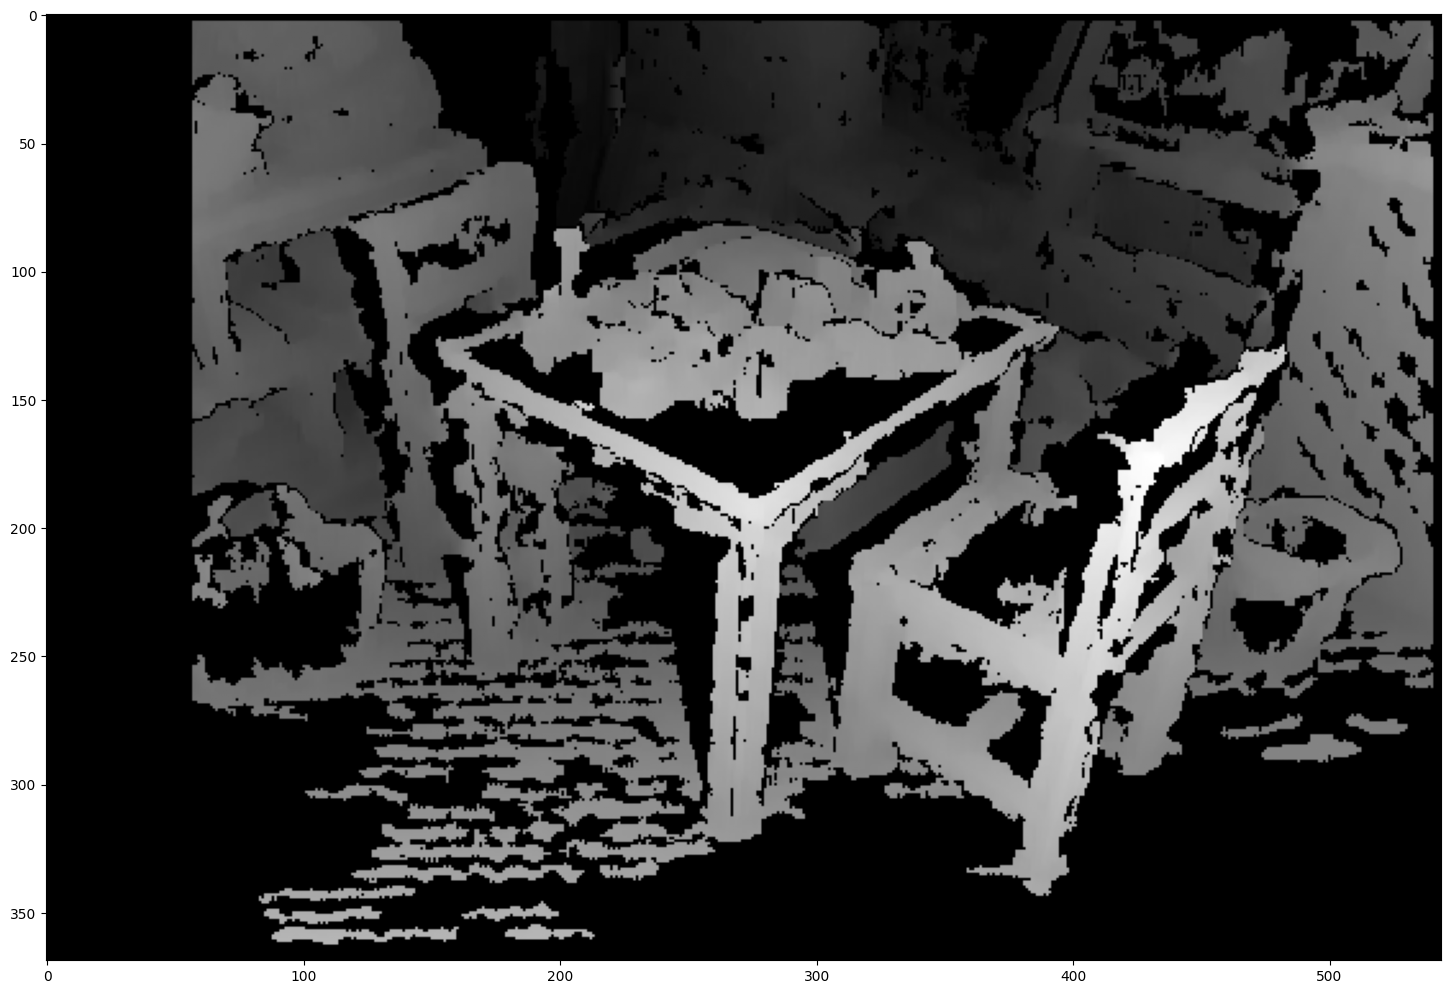

In [24]:
min_disp = 7 # Minimum disparity, the minimum pixel shift to search for between the left and right images
num_disp = 3 * 16 # Maximum disparity, the maximum pixel shift to search for between the left and right images. Must be divisible by 16.
block_size = 7 # The size of the block window to match. Must be an odd number >=1. A larger block size will give smoother disparity maps, but will reduce the accuracy of the disparity map.
stereo = cv2.StereoBM_create(numDisparities = num_disp, blockSize = block_size) 
stereo.setMinDisparity(min_disp) # Set the minimum disparity
stereo.setDisp12MaxDiff(30) # Set the maximum allowed difference in the left-right disparity check. A value of 1 means that the left and right disparity maps must match exactly, while a value of 0 means that they can differ by 1 pixel. A larger value will allow for more flexibility in the matching, but may also introduce more errors.
stereo.setUniquenessRatio(20) # Set the uniqueness ratio, which is a measure of how unique the best match is compared to the second best match. A higher value will require a more unique match, while a lower value will allow for more matches. A value of 0 means that all matches are accepted, while a value of 100 means that only the best match is accepted.
stereo.setSpeckleRange(40) # Set the speckle range, which is a measure of how much the disparity can vary within a small region. A higher value will allow for more variation, while a lower value will require more consistency. A value of 0 means that all disparities are accepted, while a value of 100 means that only disparities that are very similar to their neighbors are accepted.   
stereo.setSpeckleWindowSize(100) # Set the speckle window size, which is the size of the window used to check for speckles. A larger window size will allow for more variation, while a smaller window size will require more consistency. A value of 0 means that all disparities are accepted, while a value of 100 means that only disparities that are very similar to their neighbors are accepted.

disp = stereo.compute(gray_left, gray_right).astype(np.float32) / 16.0

plt.figure(figsize=(18,18))
plt.imshow(disp)

## Exercise 2.2
Once you have a disparity map without too much noise, you can use the below to export you disparity map to a .ply file that you can load and display in a 3D visualization software (e.g. [Meshlab](https://www.meshlab.net/#description)).

**Hint:** To open meshlab type `meshlab` in a terminal. 
To vizualize the point cloud, drag the generated `out.ply` into the meshlab scene or click `File` > `Import Mesh` and navigate to where our source-code is located and open `out.ply`. 

In [ ]:
def export_pointcloud(disparity_map, colors):
    ply_header = '''ply
    format ascii 1.0
    element vertex %(vert_num)d
    property float x
    property float y
    property float z
    property uchar red
    property uchar green
    property uchar blue
    end_header
    '''

    def write_ply(fn, verts, colors):
        verts = verts.reshape(-1, 3)
        colors = colors.reshape(-1, 3)
        verts = np.hstack([verts, colors])
        with open(fn, 'wb') as f:
            f.write((ply_header % dict(vert_num=len(verts))).encode('utf-8'))
            np.savetxt(f, verts, fmt='%f %f %f %d %d %d ')

    h, w = disparity_map.shape[:2]
    f = .8 * w  # guess for focal length. If you 3D reconstruction looks skewed in the viewing direction, try adjusting this parameter.
    Q = np.float32([[1, 0, 0, -0.5 * w],
                    [0, -1, 0, 0.5 * h],  # turn points 180 deg around x-axis,
                    [0, 0, 0, -f],  # so that y-axis looks up
                    [0, 0, 1, 0]])
    points = cv2.reprojectImageTo3D(disparity_map, Q)
    
    mask = disparity_map > disparity_map.min()
    out_points = points[mask]
    out_colors = colors[mask]
    out_fn = 'out.ply'
    write_ply('out.ply', out_points, out_colors)
    print(f'{out_fn} saved')

export_pointcloud(disparity_map=disp, colors=img_left)

## Exercise 2.3

Create a disparity map of the imageset `storage` and display it in meshlab.